# Generalized Cross-Correlation with Phase Transform

### Jimmy Jamison

Commonly used with audio sources - repurposed here for RF TDOA.

TODO


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.path.abspath('..'))
import utils

# TDOA Simulation

In this simulation, TDOA estimates are computed via cross correlation, MUSIC, and GCC-PHAT for 4 different cases, and the estimates are compared. The simulation specs are as follows:

- Over-sampled QPSK signal is received at each sensor
    - 10 samples per symbol
    - 40 symbols are received (ie signal is 400 samples)
- 20dB SNR for all receive signal components (including multipath)
- 500 samples of data collected at each sensor (ie there is some noise before and after the signal at each sensor)

Two "Scenarios" are run for all 4 cases, at different TDOAs to compare the results across different possible TDOAs.

### Scenario 1

**Case 1**
$\tau_1$ = -45

**Case 2**
$\tau_1$ = -45, $\tau_2$ = -46

**Case 3**
$\tau_1$ = -45, $\tau_2$ = -50

**Case 4**
$\tau_1$ = -45, $\tau_2$ = -46, $\tau_3$ = -50, $\tau_4$ = -51

num_samples: 500

desc: No Multipath toas0: [20] toas1: [65]
true_tdoas: [-45]

desc: Two-ray at S0 toas0: [20, 19] toas1: [65]
true_tdoas: [-46, -45]

desc: Two-ray at S1 toas0: [20] toas1: [65, 70]
true_tdoas: [-45, -50]

desc: Two-ray at Both Sensors toas0: [20, 19] toas1: [65, 70]
true_tdoas: [-46, -45, -51, -50]


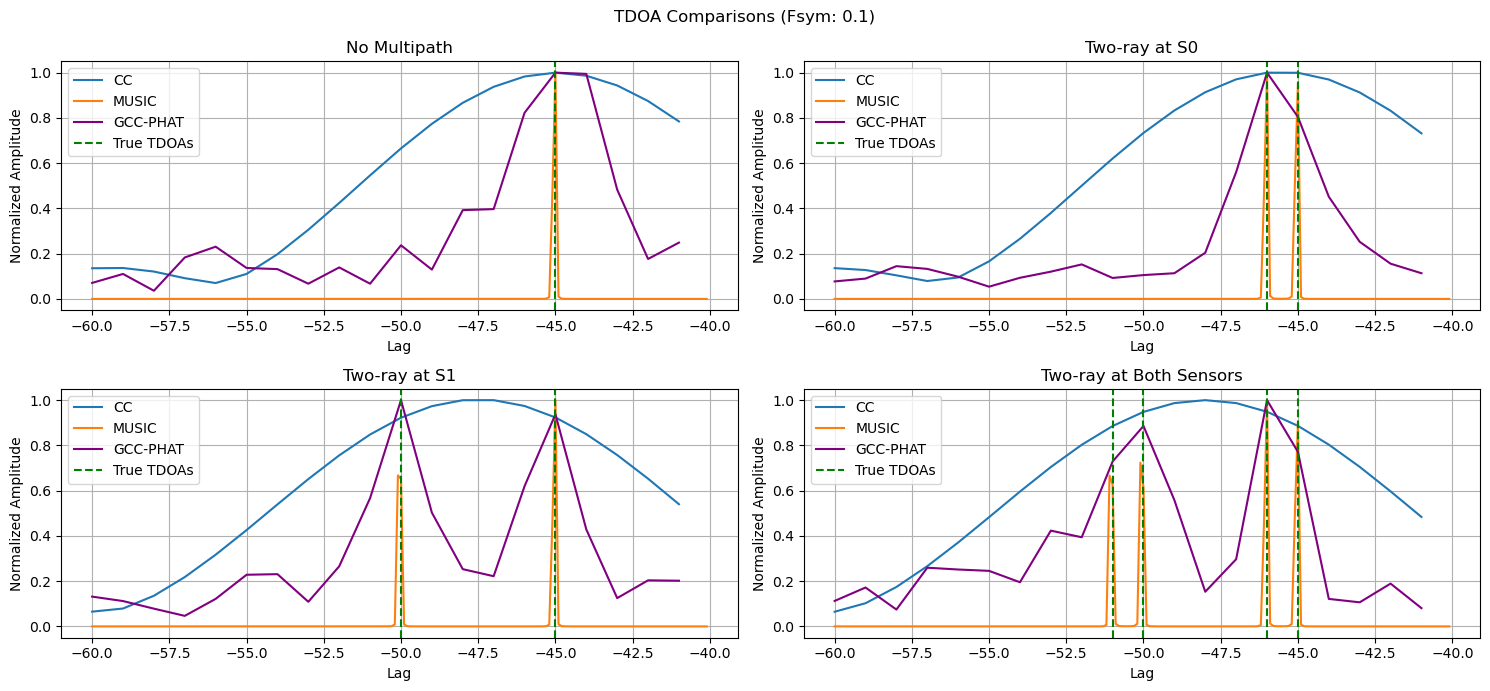

In [2]:
np.random.seed(1234)

num_symbols = 40
samples_per_symbol = 10
signal = utils.random_qpsk_data(num_symbols, samples_per_symbol, utils.Pulse.RAISED_COSINE)

num_samples = num_symbols * samples_per_symbol + 100
print(f"num_samples: {num_samples}")
snr_db = 20.

cases = {
    'No Multipath' : [[20], [65]],
    'Two-ray at S0' : [[20, 19], [65]],
    'Two-ray at S1' : [[20], [65, 70]],
    'Two-ray at Both Sensors' : [[20, 19], [65, 70]]
}

plt.figure(figsize=(15,7))
plt.suptitle(f"TDOA Comparisons (Fsym: {1/samples_per_symbol})")

pltnum = 1
for desc, (toas0, toas1) in cases.items():
    print(f"\ndesc: {desc} toas0: {toas0} toas1: {toas1}")

    snrs0 = [snr_db] * len(toas0)
    y0 = utils.sensor(signal, num_samples, toas0, snrs0)

    snrs1 = [snr_db] * len(toas1)
    y1 = utils.sensor(signal, num_samples, toas1, snrs1)

    true_tdoas = []
    for toa0 in toas0:
        for toa1 in toas1:
            true_tdoas.append(toa0-toa1)
    true_tdoas = list(set(true_tdoas))

    print(f"true_tdoas: {true_tdoas}")

    num_signals = len(true_tdoas)

    fvec = np.linspace(-0.5, 0.5, num_samples)

    l1, tdoa1 = utils.tdoa_cc(y0, y1, lag_min=-60, lag_max=-40)
    l2, tdoa2 = utils.tdoa_super(y0, y1, lag_min=-60, lag_max=-40, k=num_signals, D=10)
    l3, tdoa3 = utils.tdoa_gccphat(y0, y1, lag_min=-60, lag_max=-40)

    plt.subplot(2,2,pltnum)

    plt.title(desc)
    plt.plot(l1, tdoa1, label='CC')
    plt.plot(l2, tdoa2, label='MUSIC')
    plt.plot(l3, tdoa3, label='GCC-PHAT', color='purple')
    plt.ylabel("Normalized Amplitude")
    plt.xlabel("Lag")
    plt.grid()

    for ix,tdoa in enumerate(true_tdoas):
        if ix==0:
            plt.axvline(tdoa, color='green', linestyle='dashed', label='True TDOAs')
        else:
            plt.axvline(tdoa, color='green', linestyle='dashed')
    plt.legend()

    pltnum += 1

plt.tight_layout()

### Scenario 2

Next we slightly change the TDOAs and again compare the TDOA estimates.

**Case 1**
$\tau_1$ = -45

**Case 1**
$\tau_1$ = -45, $\tau_2$ = -47

**Case 1**
$\tau_1$ = -45, $\tau_2$ = -50

**Case 1**
$\tau_1$ = -45, $\tau_2$ = -47, $\tau_3$ = -50, $\tau_4$ = -52


desc: No Multipath toas0: [20] toas1: [65]
true_tdoas: [-45]

desc: Two-ray at S0 toas0: [20, 18] toas1: [65]
true_tdoas: [-47, -45]

desc: Two-ray at S1 toas0: [20] toas1: [67, 70]
true_tdoas: [-47, -50]

desc: Two-ray at Both Sensors toas0: [20, 18] toas1: [67, 70]
true_tdoas: [-47, -52, -50, -49]


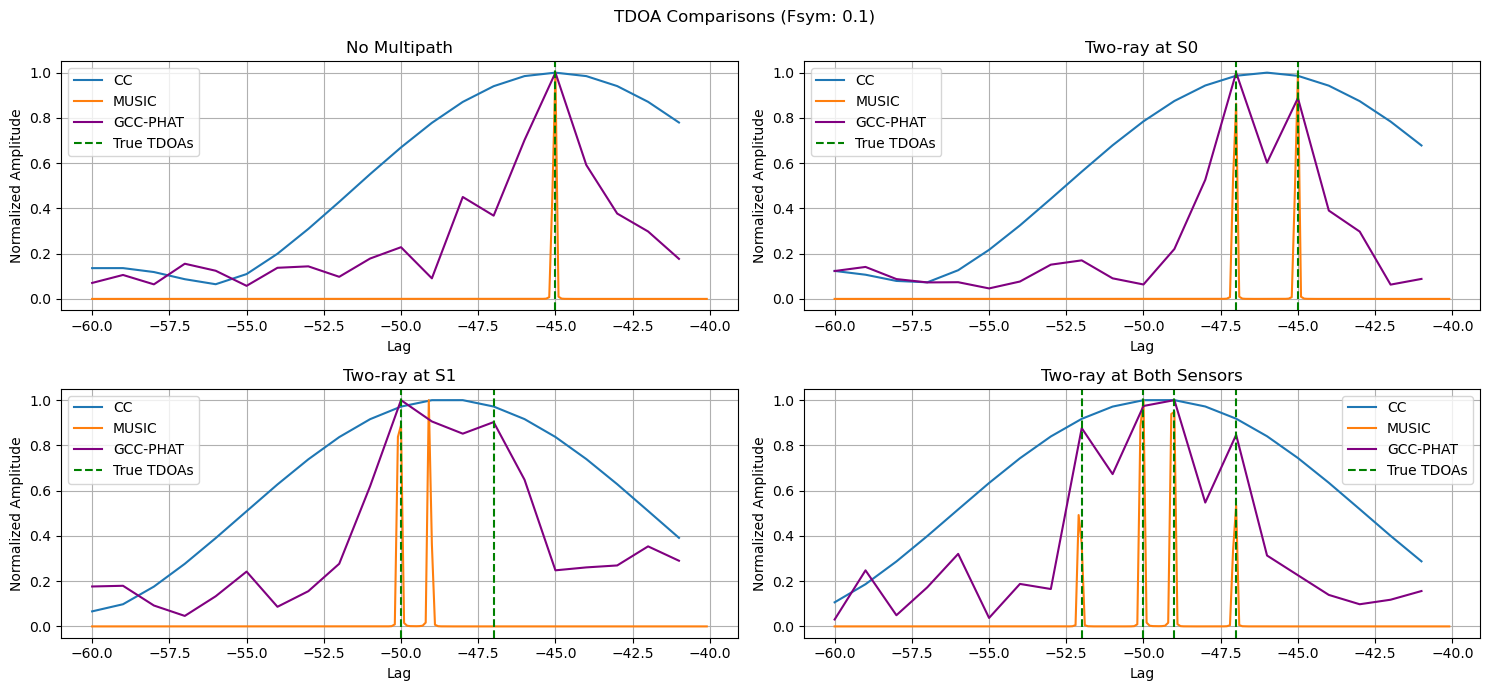

In [3]:
cases = {
    'No Multipath' : [[20], [65]],
    'Two-ray at S0' : [[20, 18], [65]],
    'Two-ray at S1' : [[20], [67, 70]],
    'Two-ray at Both Sensors' : [[20, 18], [67, 70]]
}

plt.figure(figsize=(15,7))
plt.suptitle(f"TDOA Comparisons (Fsym: {1/samples_per_symbol})")

pltnum = 1
for desc, (toas0, toas1) in cases.items():
    print(f"\ndesc: {desc} toas0: {toas0} toas1: {toas1}")

    snrs0 = [snr_db] * len(toas0)
    y0 = utils.sensor(signal, num_samples, toas0, snrs0)

    snrs1 = [snr_db] * len(toas1)
    y1 = utils.sensor(signal, num_samples, toas1, snrs1)

    true_tdoas = []
    for toa0 in toas0:
        for toa1 in toas1:
            true_tdoas.append(toa0-toa1)
    true_tdoas = list(set(true_tdoas))

    print(f"true_tdoas: {true_tdoas}")

    num_signals = len(true_tdoas)

    fvec = np.linspace(-0.5, 0.5, num_samples)

    l1, tdoa1 = utils.tdoa_cc(y0, y1, lag_min=-60, lag_max=-40)
    l2, tdoa2 = utils.tdoa_super(y0, y1, lag_min=-60, lag_max=-40, k=num_signals, D=10)
    l3, tdoa3 = utils.tdoa_gccphat(y0, y1, lag_min=-60, lag_max=-40)

    plt.subplot(2,2,pltnum)

    plt.title(desc)
    plt.plot(l1, tdoa1, label='CC')
    plt.plot(l2, tdoa2, label='MUSIC')
    plt.plot(l3, tdoa3, label='GCC-PHAT', color='purple')
    plt.ylabel("Normalized Amplitude")
    plt.xlabel("Lag")
    plt.grid()

    for ix,tdoa in enumerate(true_tdoas):
        if ix==0:
            plt.axvline(tdoa, color='green', linestyle='dashed', label='True TDOAs')
        else:
            plt.axvline(tdoa, color='green', linestyle='dashed')
    plt.legend()

    pltnum += 1

plt.tight_layout()

### Scenario 3

In this scenario we consider fractional sample TDOAs.

**Case 1**
$\tau_1$ = -45.5

**Case 1**
$\tau_1$ = -45.5, $\tau_2$ = -47

**Case 1**
$\tau_1$ = -45.5, $\tau_2$ = -50.5

**Case 1**
$\tau_1$ = -45.5, $\tau_2$ = -47, $\tau_3$ = -50.5, $\tau_4$ = -52


desc: No Multipath toas0: [20.5] toas1: [65]
true_tdoas: [-44.5]

desc: Two-ray at S0 toas0: [20.5, 18] toas1: [65]
true_tdoas: [-47, -44.5]

desc: Two-ray at S1 toas0: [20.5] toas1: [67, 70]
true_tdoas: [-46.5, -49.5]

desc: Two-ray at Both Sensors toas0: [20.5, 18] toas1: [67, 70]
true_tdoas: [-46.5, -49, -52, -49.5]


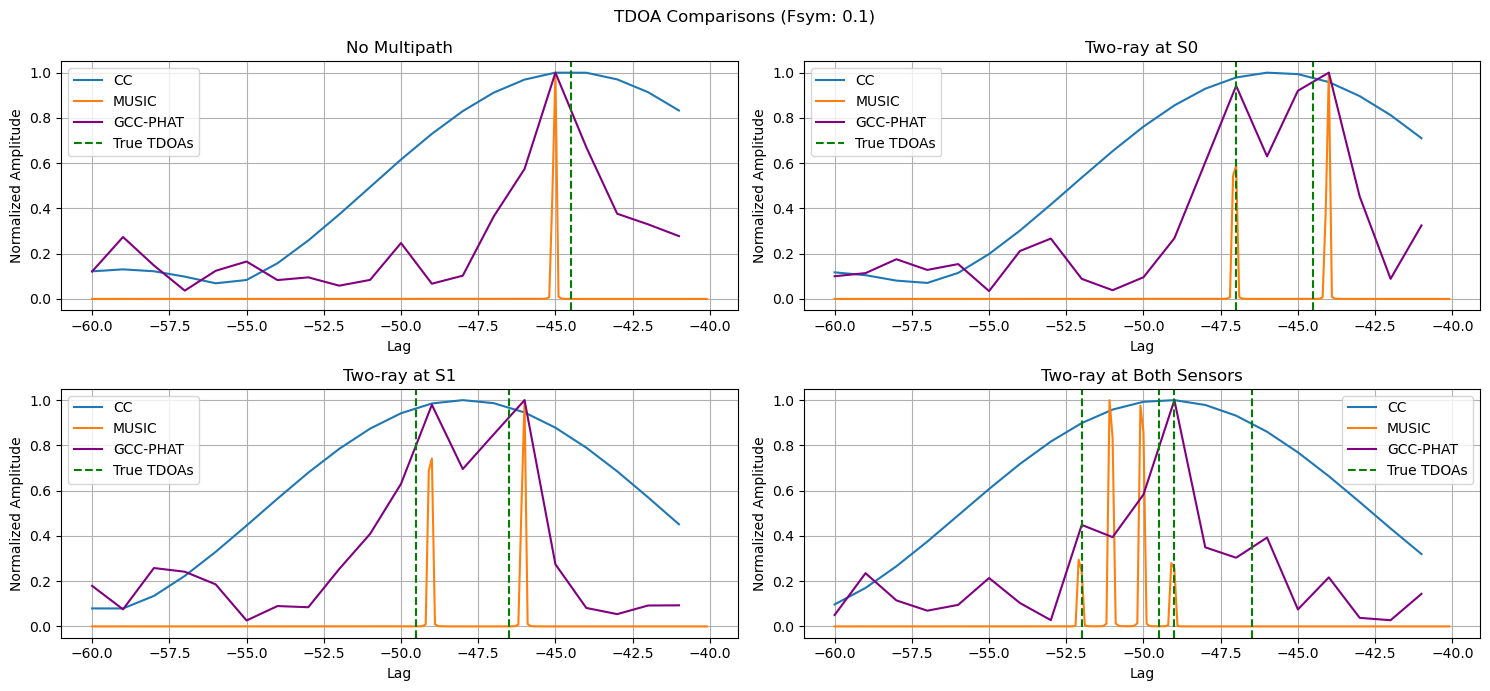

In [4]:
cases = {
    'No Multipath' : [[20.5], [65]],
    'Two-ray at S0' : [[20.5, 18], [65]],
    'Two-ray at S1' : [[20.5], [67, 70]],
    'Two-ray at Both Sensors' : [[20.5, 18], [67, 70]]
}

plt.figure(figsize=(15,7))
plt.suptitle(f"TDOA Comparisons (Fsym: {1/samples_per_symbol})")

pltnum = 1
for desc, (toas0, toas1) in cases.items():
    print(f"\ndesc: {desc} toas0: {toas0} toas1: {toas1}")

    snrs0 = [snr_db] * len(toas0)
    y0 = utils.sensor(signal, num_samples, toas0, snrs0)

    snrs1 = [snr_db] * len(toas1)
    y1 = utils.sensor(signal, num_samples, toas1, snrs1)

    true_tdoas = []
    for toa0 in toas0:
        for toa1 in toas1:
            true_tdoas.append(toa0-toa1)
    true_tdoas = list(set(true_tdoas))

    print(f"true_tdoas: {true_tdoas}")

    num_signals = len(true_tdoas)

    fvec = np.linspace(-0.5, 0.5, num_samples)

    l1, tdoa1 = utils.tdoa_cc(y0, y1, lag_min=-60, lag_max=-40)
    l2, tdoa2 = utils.tdoa_super(y0, y1, lag_min=-60, lag_max=-40, k=num_signals, D=10)
    l3, tdoa3 = utils.tdoa_gccphat(y0, y1, lag_min=-60, lag_max=-40)

    plt.subplot(2,2,pltnum)

    plt.title(desc)
    plt.plot(l1, tdoa1, label='CC')
    plt.plot(l2, tdoa2, label='MUSIC')
    plt.plot(l3, tdoa3, label='GCC-PHAT', color='purple')
    plt.ylabel("Normalized Amplitude")
    plt.xlabel("Lag")
    plt.grid()

    for ix,tdoa in enumerate(true_tdoas):
        if ix==0:
            plt.axvline(tdoa, color='green', linestyle='dashed', label='True TDOAs')
        else:
            plt.axvline(tdoa, color='green', linestyle='dashed')
    plt.legend()

    pltnum += 1

plt.tight_layout()

## Resolution Limits

This section experimentally tests the resolution limits on the three approaches to TDOA estimation.

num_samples: 500
TDOA Delta: 20
TDOA Delta: 17
TDOA Delta: 15
TDOA Delta: 12
TDOA Delta: 10


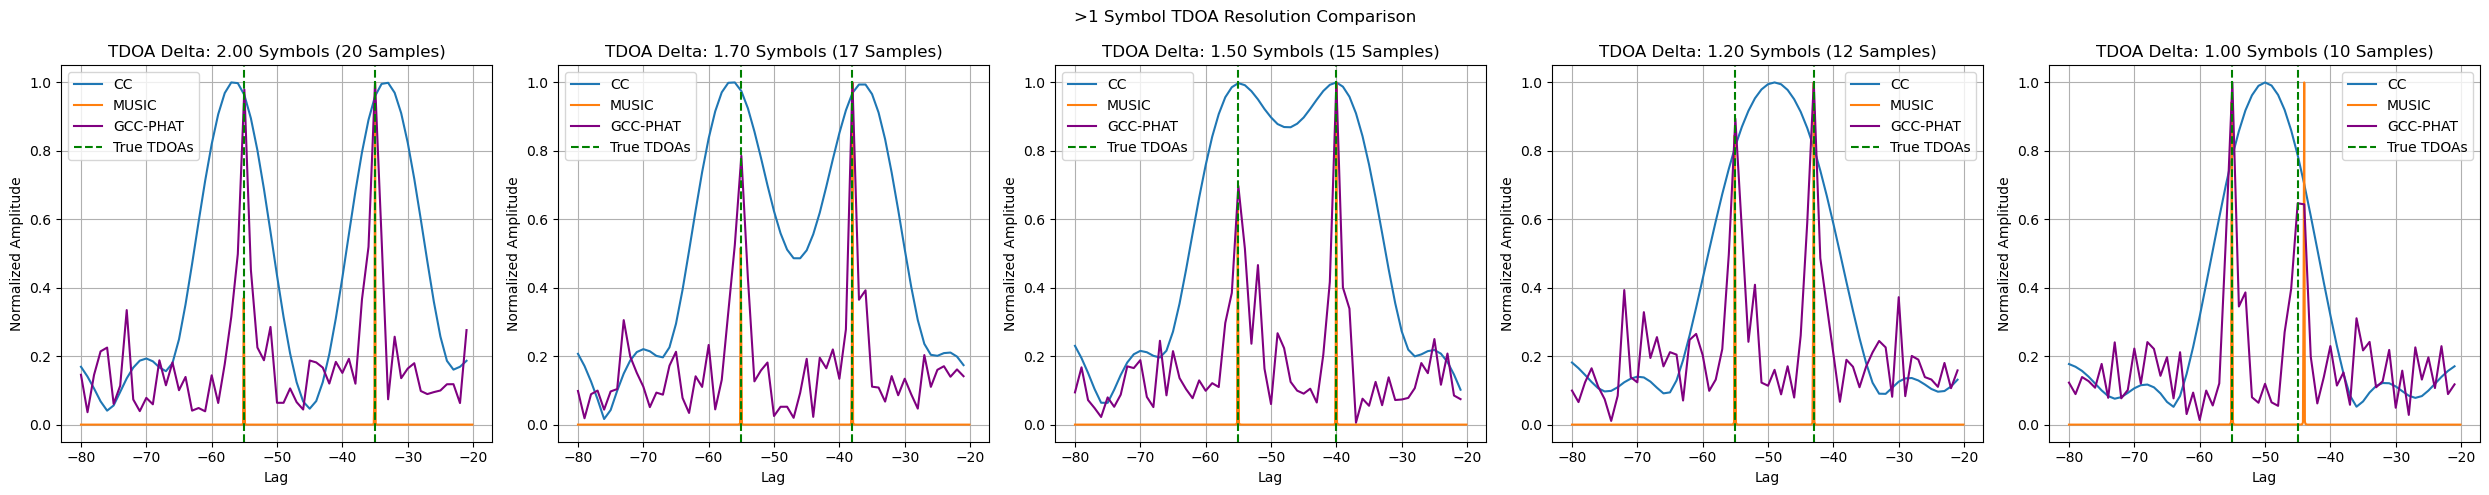

In [5]:
num_symbols = 40
samples_per_symbol = 10
signal = utils.random_qpsk_data(num_symbols, samples_per_symbol, utils.Pulse.RAISED_COSINE)

num_samples = num_symbols * samples_per_symbol + 100
print(f"num_samples: {num_samples}")
snr_db = 20.

# Cross-Correlation Resolution Boundary
plt.figure(figsize=(25,5))
plt.suptitle(">1 Symbol TDOA Resolution Comparison")

tdoa_deltas = np.array([2*samples_per_symbol, 1.75*samples_per_symbol, 1.5*samples_per_symbol, 1.25*samples_per_symbol, 1*samples_per_symbol]).astype(int)
for ix, delta in enumerate(tdoa_deltas):

    print(f"TDOA Delta: {delta}")
    tdoas = [-55, -55+delta]
    toas0 = [20]
    toas1 = [toas0[0] - tdoas[0], toas0[0] - tdoas[1]]

    snrs0 = [snr_db] * len(toas0)
    y0 = utils.sensor(signal, num_samples, toas0, snrs0)

    snrs1 = [snr_db] * len(toas1)
    y1 = utils.sensor(signal, num_samples, toas1, snrs1)

    true_tdoas = []
    for toa0 in toas0:
        for toa1 in toas1:
            true_tdoas.append(toa0-toa1)
    true_tdoas = list(set(true_tdoas))

    num_signals = len(true_tdoas)

    fvec = np.linspace(-0.5, 0.5, num_samples)

    l1, tdoa1 = utils.tdoa_cc(y0, y1, lag_min=-80, lag_max=-20)
    l2, tdoa2 = utils.tdoa_super(y0, y1, lag_min=-80, lag_max=-20, k=num_signals, D=10)
    l3, tdoa3 = utils.tdoa_gccphat(y0, y1, lag_min=-80, lag_max=-20)

    plt.subplot(1,len(tdoa_deltas),ix+1)
    plt.title(f"TDOA Delta: {delta/samples_per_symbol:.2f} Symbols ({delta} Samples)")
    plt.plot(l1, tdoa1, label='CC')
    plt.plot(l2, tdoa2, label='MUSIC')
    plt.plot(l3, tdoa3, label='GCC-PHAT', color='purple')
    plt.ylabel("Normalized Amplitude")
    plt.xlabel("Lag")
    plt.grid()

    for ix,tdoa in enumerate(true_tdoas):
        if ix==0:
            plt.axvline(tdoa, color='green', linestyle='dashed', label='True TDOAs')
        else:
            plt.axvline(tdoa, color='green', linestyle='dashed')
    plt.legend()

plt.tight_layout()

TDOA Delta: 10
TDOA Delta: 8
TDOA Delta: 6
TDOA Delta: 4
TDOA Delta: 2


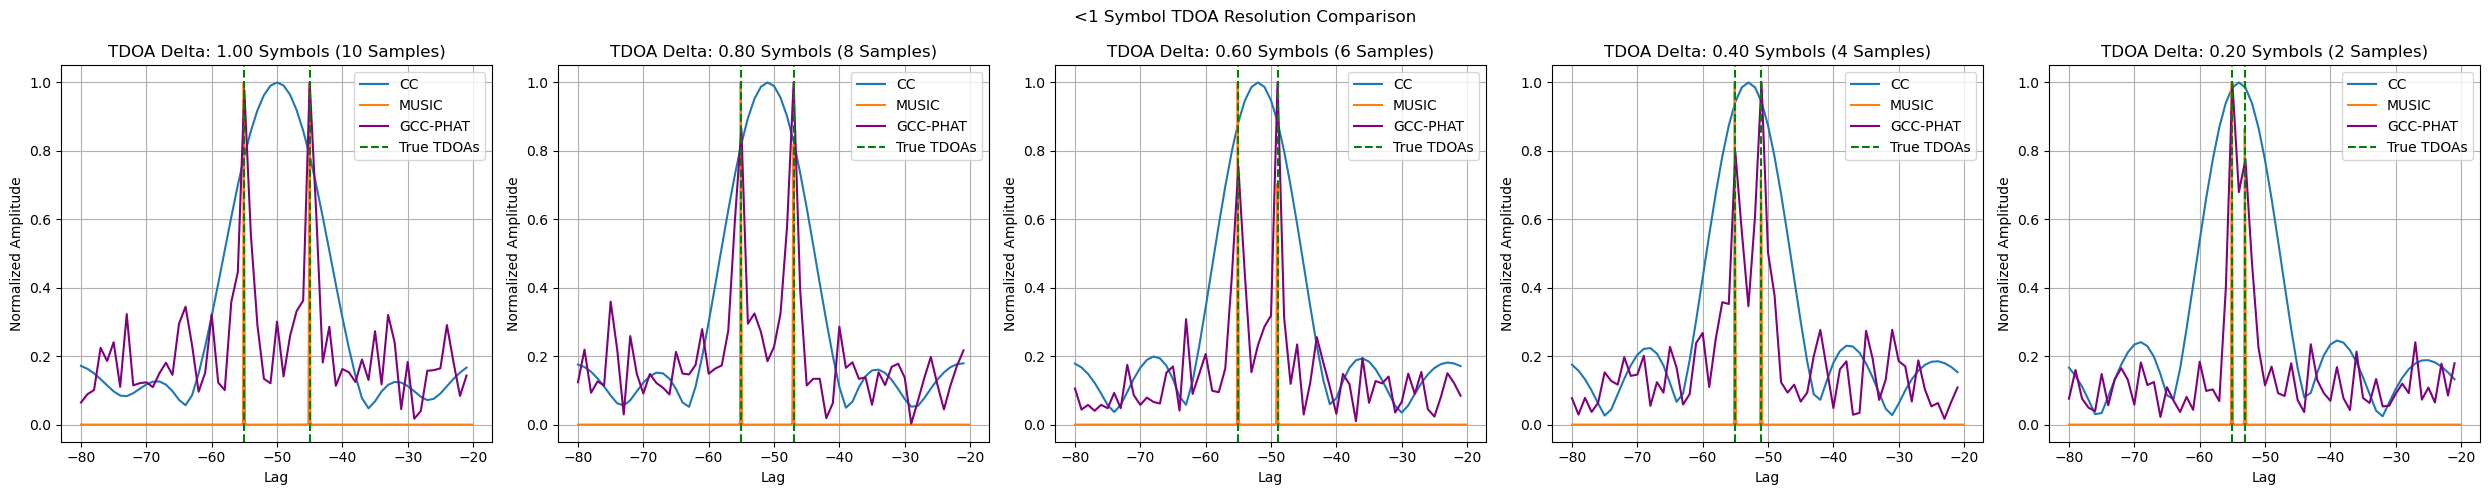

In [6]:
# Cross-Correlation Resolution Boundary
plt.figure(figsize=(25,5))
plt.suptitle("<1 Symbol TDOA Resolution Comparison")

tdoa_deltas = np.array([10, 8, 6, 4, 2]).astype(int)
for ix, delta in enumerate(tdoa_deltas):

    print(f"TDOA Delta: {delta}")
    tdoas = [-55, -55+delta]
    toas0 = [20]
    toas1 = [toas0[0] - tdoas[0], toas0[0] - tdoas[1]]

    snrs0 = [snr_db] * len(toas0)
    y0 = utils.sensor(signal, num_samples, toas0, snrs0)

    snrs1 = [snr_db] * len(toas1)
    y1 = utils.sensor(signal, num_samples, toas1, snrs1)

    true_tdoas = []
    for toa0 in toas0:
        for toa1 in toas1:
            true_tdoas.append(toa0-toa1)
    true_tdoas = list(set(true_tdoas))

    num_signals = len(true_tdoas)

    fvec = np.linspace(-0.5, 0.5, num_samples)

    l1, tdoa1 = utils.tdoa_cc(y0, y1, lag_min=-80, lag_max=-20)
    l2, tdoa2 = utils.tdoa_super(y0, y1, lag_min=-80, lag_max=-20, k=num_signals, D=10)
    l3, tdoa3 = utils.tdoa_gccphat(y0, y1, lag_min=-80, lag_max=-20)

    plt.subplot(1,len(tdoa_deltas),ix+1)
    plt.title(f"TDOA Delta: {delta/samples_per_symbol:.2f} Symbols ({delta} Samples)")
    plt.plot(l1, tdoa1, label='CC')
    plt.plot(l2, tdoa2, label='MUSIC')
    plt.plot(l3, tdoa3, label='GCC-PHAT', color='purple')
    plt.ylabel("Normalized Amplitude")
    plt.xlabel("Lag")
    plt.grid()

    for ix,tdoa in enumerate(true_tdoas):
        if ix==0:
            plt.axvline(tdoa, color='green', linestyle='dashed', label='True TDOAs')
        else:
            plt.axvline(tdoa, color='green', linestyle='dashed')
    plt.legend()

plt.tight_layout()